# 🎬 Personalized Movie Recommendation System using a Two-Tower Neural Network

## Overview

This notebook demonstrates the complete machine learning pipeline used to build the recommendation engine powering **KINORA**, a personalized movie recommendation web application.

The recommendation system is based on a **Two-Tower Neural Network**, where separate neural networks learn latent representations (embeddings) for users and movies. These embeddings are projected into a shared vector space, enabling personalized recommendations through cosine similarity.

Unlike traditional recommendation approaches that rely solely on popularity or user-item interactions, this model learns meaningful user preferences and movie characteristics, allowing it to recommend movies that better match an individual's taste.

---

## Dataset

This project is trained using the **MovieLens** dataset, containing millions of movie ratings collected from real users. Movie metadata such as genres and release year are incorporated during feature engineering to improve recommendation quality.

---

## Objectives

The primary goals of this notebook are:

- Load and preprocess the MovieLens dataset.
- Engineer meaningful features for both users and movies.
- Build a Two-Tower Neural Network using TensorFlow.
- Train the model to learn user and movie embeddings.
- Evaluate the recommendation model.
- Generate normalized embeddings for efficient similarity search.
- Save the trained models and preprocessing objects for deployment in the KINORA web application.

---

## Technologies Used

- Python
- TensorFlow / Keras
- NumPy
- Pandas
- Scikit-learn

---

## Workflow

The notebook follows the following pipeline:

1. Data Loading
2. Data Preprocessing
3. Feature Engineering
4. User & Movie Feature Construction
5. Two-Tower Model Architecture
6. Model Training
7. Model Evaluation
8. Embedding Generation
9. Recommendation Inference
10. Model Export for Deployment

In [1]:
import numpy as np
import pandas as pd
import tensorflow as tf
import joblib

C:\Users\hp\anaconda3\Lib\site-packages\keras\src\export\tf2onnx_lib.py:8: FutureWarning: In the future `np.object` will be defined as the corresponding NumPy scalar.
  if not hasattr(np, "object"):


# Data Loading

The MovieLens dataset is loaded into two DataFrames:

- **movies.csv** – Contains movie metadata including titles and genres.
- **ratings.csv** – Contains user ratings for movies.

These datasets form the foundation for feature engineering and model training.

In [2]:
movies_df=pd.read_csv('data/movies.csv',encoding='utf-8')
movies_df.head()

,movieId,title,genres
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,2,Jumanji (1995),Adventure|Children|Fantasy
2,3,Grumpier Old Men (1995),Comedy|Romance
3,4,Waiting to Exhale (1995),Comedy|Drama|Romance
4,5,Father of the Bride Part II (1995),Comedy


In [3]:
ratings_df = pd.read_csv("data/ratings.csv",encoding='utf-8')
ratings_df.head()

,userId,movieId,rating,timestamp
0,1,17,4.0,944249077
1,1,25,1.0,944250228
2,1,29,2.0,943230976
3,1,30,5.0,944249077
4,1,32,5.0,943228858


In [4]:
#Overview

print("Movies:", len(movies_df))
print("Ratings:", len(ratings_df))

print("Unique users:", ratings_df.userId.nunique())
print("Unique movies:", ratings_df.movieId.nunique())

Movies: 87585
Ratings: 32000204
Unique users: 200948
Unique movies: 84432


## Exploratory Data Analysis

Initial exploration of the dataset is performed to examine the distribution of ratings and movie genres before preprocessing and feature engineering.

In [5]:
ratings_df.rating.value_counts().sort_index()

rating
0.5     525132
1.0     946675
1.5     531063
2.0    2028622
2.5    1685386
3.0    6054990
3.5    4290105
4.0    8367654
4.5    2974000
5.0    4596577
Name: count, dtype: int64

In [6]:
movies_df['genres'].str.get_dummies('|').sum().sort_values(ascending=False)

Drama                 34175
Comedy                23124
Thriller              11823
Romance               10369
Action                 9668
Documentary            9363
Horror                 8654
(no genres listed)     7080
Crime                  6976
Adventure              5402
Sci-Fi                 4907
Animation              4617
Children               4520
Mystery                4013
Fantasy                3851
War                    2325
Western                1696
Musical                1059
Film-Noir               353
IMAX                    195
dtype: int64

## Dataset Sampling

To reduce computational cost during training, a reproducible subset of five million ratings is sampled from the original MovieLens dataset.

In [7]:
ratings_df = ratings_df.sample(n=5_000_000,random_state=42)
print(ratings_df.shape)

(5000000, 4)


# Data Preprocessing

Movie release years are extracted from movie titles, converted to numeric values, and cleaned by removing entries with missing release years.

In [8]:
movies_df["year"] = (
    pd.to_numeric(
        movies_df["title"].str.extract(r"\((\d{4})\)")[0],
        errors="coerce"
    )
)
movies_df = movies_df.dropna(subset=["year"])
movies_df["year"] = movies_df["year"].astype(int)
movies_df[["title", "year"]].head()

,title,year
0,Toy Story (1995),1995
1,Jumanji (1995),1995
2,Grumpier Old Men (1995),1995
3,Waiting to Exhale (1995),1995
4,Father of the Bride Part II (1995),1995


In [9]:
movies_df["year"].isna().sum()

np.int64(0)

In [10]:
#Normalizing Year
from sklearn.preprocessing import MinMaxScaler

year_scaler = MinMaxScaler()

movies_df["year_scaled"] = year_scaler.fit_transform(
    movies_df[["year"]]
    .astype("float32")
)
movies_df[["year", "year_scaled"]].head()

,year,year_scaled
0,1995,0.812081
1,1995,0.812081
2,1995,0.812081
3,1995,0.812081
4,1995,0.812081


### Memory Optimization

To improve training efficiency, numeric columns were converted to smaller data types where appropriate.

- `userId`, `movieId`, `year` → `int32`
- `rating`, `year_scaled` → `float32`
- Multi-hot encoded genre features → `int8`

These optimizations reduced the memory footprint of the training dataset from approximately **800 MB to 250 MB** without affecting model performance.

In [11]:
movies_df["year"] = movies_df["year"].astype("int32")

ratings_df["userId"] = ratings_df["userId"].astype("int32")
ratings_df["movieId"] = ratings_df["movieId"].astype("int32")
ratings_df["rating"] = ratings_df["rating"].astype("float32")

# Feature Engineering

Movie genres are transformed into multi-hot encoded vectors, while release years are normalized using Min-Max scaling. These engineered features form part of the movie representation used by the recommendation model.

In [12]:
genre_features = movies_df["genres"].str.get_dummies(sep="|")
genre_features = genre_features.drop(columns=["(no genres listed)"],errors="ignore")
genre_features.head()
genre_features = genre_features.astype("int8") #for memory optimization

The movie feature vector is constructed by combining the multi-hot encoded genre features with the normalized release year. Each movie is represented by a fixed-length feature vector that serves as the input to the movie tower of the recommendation model.

In [13]:
movie_features = pd.concat(
    [
        genre_features,
        movies_df[["year_scaled"]]
    ],
    axis=1
)
movie_features.head()

,Action,Adventure,Animation,Children,Comedy,Crime,Documentary,Drama,Fantasy,Film-Noir,Horror,IMAX,Musical,Mystery,Romance,Sci-Fi,Thriller,War,Western,year_scaled
0,0,1,1,1,1,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0.812081
1,0,1,0,1,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0.812081
2,0,0,0,0,1,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0.812081
3,0,0,0,0,1,0,0,1,0,0,0,0,0,0,1,0,0,0,0,0.812081
4,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.812081


In [14]:
movie_feature_df = movie_features.copy()
movie_feature_df.index = movies_df["movieId"]

In [15]:
print(movie_feature_df.shape)
print(movie_feature_df.columns.tolist())

(86970, 20)
['Action', 'Adventure', 'Animation', 'Children', 'Comedy', 'Crime', 'Documentary', 'Drama', 'Fantasy', 'Film-Noir', 'Horror', 'IMAX', 'Musical', 'Mystery', 'Romance', 'Sci-Fi', 'Thriller', 'War', 'Western', 'year_scaled']


In [16]:
train_df = ratings_df.merge(
    movie_feature_df,
    left_on="movieId",
    right_index=True
)
train_df.head()

,userId,movieId,rating,timestamp,Action,Adventure,Animation,Children,Comedy,Crime,...,Horror,IMAX,Musical,Mystery,Romance,Sci-Fi,Thriller,War,Western,year_scaled
10685861,66954,781,5.0,850944577,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0.818792
1552723,9877,574,4.0,945495614,0,0,0,0,1,0,...,0,0,0,0,0,0,0,0,0,0.805369
6145184,38348,1088,2.0,999974867,0,0,0,0,0,0,...,0,0,1,0,1,0,0,0,0,0.758389
16268584,101952,2706,1.0,1203077565,0,0,0,0,1,0,...,0,0,0,0,1,0,0,0,0,0.838926
22418634,140400,275079,3.5,1653782463,0,1,1,1,1,0,...,0,0,0,1,0,0,0,0,0,0.993289


# User and Movie Feature Construction

The raw user and movie data are preprocessed to create numerical feature matrices for model training.

- **User Features (`Xu`)**: User attributes are cleaned, encoded, and transformed into a fixed-length feature vector for each user.
- **Movie Features (`Xm`)**: Movie metadata, including release year and genre information, is processed into a numerical feature vector for each movie.

These feature matrices are then merged with the ratings dataset using `userId` and `movieId`, producing the final training dataset where each interaction contains the corresponding user features, movie features, and rating.

In [17]:
rating_map = {
    0.5: -2.0,
    1.0: -1.5,
    1.5: -1.0,
    2.0: -0.5,
    2.5: 0.0,
    3.0: 0.5,
    3.5: 1.0,
    4.0: 1.5,
    4.5: 2.0,
    5.0: 2.5
}

train_df["rating_weight"] = train_df["rating"].map(rating_map)

In [18]:
genre_cols = genre_features.columns

In [19]:
weighted_features = (
    train_df[genre_cols]
    .mul(train_df["rating_weight"], axis=0)
)

user_feature_sum = (
    weighted_features
    .groupby(train_df["userId"])
    .sum()
)

weight_sum = (
    train_df["rating_weight"]
    .abs()
    .groupby(train_df["userId"])
    .sum()
)

xu_df = user_feature_sum.div(
    weight_sum,
    axis=0
)

In [20]:
# Average rating given by each user
user_avg_rating = (
    ratings_df.groupby("userId")["rating"]
    .mean()
    .rename("avg_rating")
)

# Number of ratings given by each user
user_rating_count = (
    ratings_df.groupby("userId")
    .size()
    .rename("rating_count")
)

xu_final = xu_df.join(user_avg_rating)
xu_final = xu_final.join(user_rating_count)

In [21]:
xu_final = xu_final.reset_index()
xu_final.columns

Index(['userId', 'Action', 'Adventure', 'Animation', 'Children', 'Comedy',
       'Crime', 'Documentary', 'Drama', 'Fantasy', 'Film-Noir', 'Horror',
       'IMAX', 'Musical', 'Mystery', 'Romance', 'Sci-Fi', 'Thriller', 'War',
       'Western', 'avg_rating', 'rating_count'],
      dtype='object')

In [22]:
xm_final=movie_feature_df
xm_final=xm_final.reset_index()
xm_final.columns

Index(['movieId', 'Action', 'Adventure', 'Animation', 'Children', 'Comedy',
       'Crime', 'Documentary', 'Drama', 'Fantasy', 'Film-Noir', 'Horror',
       'IMAX', 'Musical', 'Mystery', 'Romance', 'Sci-Fi', 'Thriller', 'War',
       'Western', 'year_scaled'],
      dtype='object')

In [23]:
full_df = ratings_df.merge(
    xu_final,
    on="userId"
)

full_df = full_df.merge(
    xm_final,
    on="movieId"
)

In [24]:
full_df = full_df.dropna()

In [25]:
full_df.isnull().sum().sum()

np.int64(0)

In [26]:
full_df.shape

(4994419, 45)

In [27]:
full_df.head()

,userId,movieId,rating,timestamp,Action_x,Adventure_x,Animation_x,Children_x,Comedy_x,Crime_x,...,Horror_y,IMAX_y,Musical_y,Mystery_y,Romance_y,Sci-Fi_y,Thriller_y,War_y,Western_y,year_scaled
0,66954,781,5.0,850944577,0.033898,0.033898,0.000000,0.000000,0.372881,0.271186,...,0,0,0,0,0,0,0,0,0,0.818792
1,9877,574,4.0,945495614,0.072464,0.060870,0.023188,0.052174,0.260870,0.084058,...,0,0,0,0,0,0,0,0,0,0.805369
2,38348,1088,2.0,999974867,-0.013605,0.081633,0.006803,0.108844,0.251701,0.068027,...,0,0,1,0,1,0,0,0,0,0.758389
3,101952,2706,1.0,1203077565,0.040816,0.051020,0.000000,0.030612,-0.091837,0.020408,...,0,0,0,0,1,0,0,0,0,0.838926
4,140400,275079,3.5,1653782463,0.217391,0.178261,0.089130,0.065217,0.289130,0.136957,...,0,0,0,1,0,0,0,0,0,0.993289


## Final Feature Matrices

The final input features for the recommendation model are separated into user and movie feature matrices. User features include genre preferences and behavioral statistics, while movie features consist of genre indicators and the normalized release year.

In [28]:
user_cols = [
    col for col in full_df.columns
    if col.endswith("_x")
]

user_cols += [
    "avg_rating",
    "rating_count"
]

print(user_cols)

['Action_x', 'Adventure_x', 'Animation_x', 'Children_x', 'Comedy_x', 'Crime_x', 'Documentary_x', 'Drama_x', 'Fantasy_x', 'Film-Noir_x', 'Horror_x', 'IMAX_x', 'Musical_x', 'Mystery_x', 'Romance_x', 'Sci-Fi_x', 'Thriller_x', 'War_x', 'Western_x', 'avg_rating', 'rating_count']


In [29]:
movie_cols = [
    col for col in full_df.columns
    if col.endswith("_y")
]
movie_cols += ["year_scaled"]
print(movie_cols)

['Action_y', 'Adventure_y', 'Animation_y', 'Children_y', 'Comedy_y', 'Crime_y', 'Documentary_y', 'Drama_y', 'Fantasy_y', 'Film-Noir_y', 'Horror_y', 'IMAX_y', 'Musical_y', 'Mystery_y', 'Romance_y', 'Sci-Fi_y', 'Thriller_y', 'War_y', 'Western_y', 'year_scaled']


In [30]:
print("Lenght of User Col: ",len(user_cols))
print("Lenght of Movie Col: ",len(movie_cols))

Lenght of User Col:  21
Lenght of Movie Col:  20


In [31]:
full_df[["avg_rating", "rating_count"]].head()

,avg_rating,rating_count
0,4.235294,17
1,3.435115,131
2,2.880000,75
3,3.205882,34
4,3.530516,213


In [32]:
#Normalizing average rating and rating count
user_scaler = MinMaxScaler()

full_df[["avg_rating", "rating_count"]] = user_scaler.fit_transform(
    full_df[["avg_rating", "rating_count"]]
)

y_scaler = MinMaxScaler()

y = y_scaler.fit_transform(
    full_df[["rating"]]
).flatten()

In [33]:
#Building final user and movie vector
Xu = full_df[user_cols]
Xm = full_df[movie_cols]

## Model Preparation

The user feature matrix, movie feature matrix, and target ratings are prepared for training. All inputs are converted to `float32` for compatibility with TensorFlow and memory optimization, followed by an 80–20 train-test split.

In [34]:
#Memory Optimization
Xu = Xu.astype("float32")
Xm = Xm.astype("float32")
y = y.astype("float32")

In [35]:
print("Xu shape: ",Xu.shape)
print("Xm shape: ",Xm.shape)
print("Y shape: ",y.shape)

Xu shape:  (4994419, 21)
Xm shape:  (4994419, 20)
Y shape:  (4994419,)


In [36]:
from sklearn.model_selection import train_test_split
Xu_train, Xu_test, Xm_train, Xm_test, y_train, y_test = train_test_split(
    Xu,
    Xm,
    y,
    test_size=0.2,
    random_state=42,
    shuffle=True
)

In [37]:
Xu_train = Xu_train.values
Xu_test  = Xu_test.values

Xm_train = Xm_train.values
Xm_test  = Xm_test.values

y_train = y_train
y_test  = y_test

In [38]:
print(Xu_train.shape)
print(Xm_train.shape)
print(y_train.shape)

print(Xu_test.shape)
print(Xm_test.shape)
print(y_test.shape)

(3995535, 21)
(3995535, 20)
(3995535,)
(998884, 21)
(998884, 20)
(998884,)


In [39]:
print(type(Xu_train))
print(type(Xm_train))
print(type(y_train))

print(Xu_train.dtype)
print(Xm_train.dtype)
print(y_train.dtype)

<class 'numpy.ndarray'>
<class 'numpy.ndarray'>
<class 'numpy.ndarray'>
float32
float32
float32


# Two-Tower Model Architecture

The recommendation model consists of two independent neural networks:

- **User Tower** – Learns dense embeddings from user preference features.
- **Movie Tower** – Learns dense embeddings from movie metadata.

Both towers project their inputs into a shared embedding space of 32 dimensions. The resulting embeddings are L2-normalized, and their similarity is computed using the dot product, enabling personalized recommendations based on embedding similarity.

In [40]:
num_output=32
tf.random.set_seed(1)
user_NN=tf.keras.models.Sequential([
    tf.keras.layers.Dense(256,activation='gelu'),
    tf.keras.layers.Dense(128,activation='gelu'),
    tf.keras.layers.Dense(num_output,activation='linear')
])

movie_NN=tf.keras.models.Sequential([
    tf.keras.layers.Dense(256,activation='gelu'),
    tf.keras.layers.Dense(128,activation='gelu'),
    tf.keras.layers.Dense(num_output,activation='linear')
])

In [41]:
num_user_features=Xu_train.shape[1]
num_movie_features=Xm_train.shape[1]

input_user = tf.keras.layers.Input(shape=(num_user_features,))
vu = user_NN(input_user)
vu = tf.keras.layers.Lambda(
    lambda x: tf.linalg.l2_normalize(x, axis=1)
)(vu)

# create the item input and point to the base network
input_movie = tf.keras.layers.Input(shape=(num_movie_features,))
vm = movie_NN(input_movie)
vm = tf.keras.layers.Lambda(
    lambda x: tf.linalg.l2_normalize(x, axis=1)
)(vm)

# compute the dot product of the two vectors vu and vm
output = tf.keras.layers.Dot(axes=1)([vu, vm])

# specify the inputs and output of the model
model = tf.keras.Model([input_user, input_movie], output)
model.summary()

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                  ┃ Output Shape              ┃         Param # ┃ Connected to               ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)      │ (None, 21)                │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ input_layer_2 (InputLayer)    │ (None, 20)                │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ sequential (Sequential)       │ (None, 32)                │          42,656 │ input_layer[0][0]          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ sequential_1 (Sequential)     │ (None, 32)                │          42,400 │ input_layer_2[0][0]        │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ lambda (Lambda)               │ (None, 32)                │               0 │ sequential[0][0]           │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ lambda_1 (Lambda)             │ (None, 32)                │               0 │ sequential_1[0][0]         │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dot (Dot)                     │ (None, 1)                 │               0 │ lambda[0][0],              │
│                               │                           │                 │ lambda_1[0][0]             │
└───────────────────────────────┴───────────────────────────┴─────────────────┴────────────────────────────┘

 Total params: 85,056 (332.25 KB)

 Trainable params: 85,056 (332.25 KB)

 Non-trainable params: 0 (0.00 B)

# Model Training

The model is trained using the Adam optimizer with Mean Squared Error (MSE) loss. Training is performed for 30 epochs using a batch size of 1024 while monitoring validation performance.

In [42]:
tf.random.set_seed(1)
cost_fn = tf.keras.losses.MeanSquaredError()
opt = tf.keras.optimizers.Adam(learning_rate=0.001)
model.compile(optimizer=opt,loss=cost_fn)

In [43]:
tf.random.set_seed(1)
history=model.fit([Xu_train,Xm_train],y_train,validation_data=([Xu_test, Xm_test],y_test),epochs=30,batch_size=1024)

Epoch 1/30
3902/3902 ━━━━━━━━━━━━━━━━━━━━ 73s 18ms/step - loss: 0.0360 - val_loss: 0.0348
Epoch 2/30
3902/3902 ━━━━━━━━━━━━━━━━━━━━ 74s 19ms/step - loss: 0.0345 - val_loss: 0.0341
Epoch 3/30
3902/3902 ━━━━━━━━━━━━━━━━━━━━ 69s 18ms/step - loss: 0.0338 - val_loss: 0.0336
Epoch 4/30
3902/3902 ━━━━━━━━━━━━━━━━━━━━ 68s 17ms/step - loss: 0.0334 - val_loss: 0.0332
Epoch 5/30
3902/3902 ━━━━━━━━━━━━━━━━━━━━ 71s 18ms/step - loss: 0.0330 - val_loss: 0.0328
Epoch 6/30
3902/3902 ━━━━━━━━━━━━━━━━━━━━ 69s 18ms/step - loss: 0.0327 - val_loss: 0.0326
Epoch 7/30
3902/3902 ━━━━━━━━━━━━━━━━━━━━ 68s 17ms/step - loss: 0.0324 - val_loss: 0.0324
Epoch 8/30
3902/3902 ━━━━━━━━━━━━━━━━━━━━ 67s 17ms/step - loss: 0.0322 - val_loss: 0.0322
Epoch 9/30
3902/3902 ━━━━━━━━━━━━━━━━━━━━ 69s 18ms/step - loss: 0.0321 - val_loss: 0.0321
Epoch 10/30
3902/3902 ━━━━━━━━━━━━━━━━━━━━ 71s 18ms/step - loss: 0.0320 - val_loss: 0.0320
Epoch 11/30
3902/3902 ━━━━━━━━━━━━━━━━━━━━ 69s 18ms/step - loss: 0.0319 - val_loss: 0.0319
Epoch 12

# Model Evaluation

Training and validation loss are monitored throughout the training process to evaluate convergence and detect potential overfitting.

## 1. Training Performance

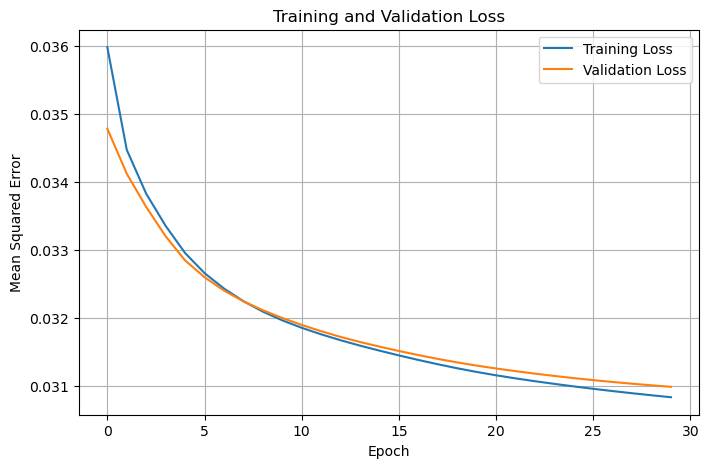

In [44]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Mean Squared Error")
plt.title("Training and Validation Loss")
plt.legend()
plt.grid(True)
#plt.savefig("graphs/loss_vs_epochs.png")
plt.show()


## 2. Quantitative Evaluation

In [45]:
#Mean Square Error
test_loss = model.evaluate([Xu_test, Xm_test],y_test,verbose=0)

print(f"Test MSE: {test_loss:.4f}")

Test MSE: 0.0310


## 3. Prediction Quality

In [46]:
pred = model.predict([Xu_test, Xm_test],verbose=0).flatten()

#convert to original scale
pred_rating = y_scaler.inverse_transform(pred.reshape(-1,1)).flatten()
true_rating = y_scaler.inverse_transform(y_test.reshape(-1,1)).flatten()

In [47]:
from sklearn.metrics import mean_squared_error, mean_absolute_error

rmse = mean_squared_error(true_rating,pred_rating) ** 0.5
mae = mean_absolute_error(true_rating,pred_rating)

print("RMSE:", rmse)
print("MAE :", mae)

RMSE: 0.7920610089862582
MAE : 0.6110034584999084


### Test Set Performance

The trained model was evaluated on a held-out test set using regression metrics.

| Metric | Value |
|--------|-------:|
| Mean Squared Error (MSE) | 0.0310 *(normalized scale)* |
| Root Mean Squared Error (RMSE) | 0.7922 |
| Mean Absolute Error (MAE) | 0.6112 |

The relatively low RMSE and MAE indicate that the model is able to predict user ratings with reasonable accuracy while learning meaningful user and movie representations.

## 4. Reccomendation Quality

In [48]:
demo_ratings = {
    "Titanic (1997)": 5.0,
    "Pride & Prejudice (2005)": 5.0,
    "La La Land (2016)": 4.5,
    "Before Sunrise (1995)": 4.5,
}

In [49]:
demo_movies = movies_df[
    movies_df["title"].isin(demo_ratings.keys())
].copy()

demo_movies

,movieId,title,genres,year,year_scaled
213,215,Before Sunrise (1995),Drama|Romance,1995,0.812081
1655,1721,Titanic (1997),Drama|Romance,1997,0.825503
10403,40629,Pride & Prejudice (2005),Drama|Romance,2005,0.879195
43387,164909,La La Land (2016),Comedy|Drama|Romance,2016,0.953020


In [50]:
demo_movies["rating"] = demo_movies["title"].map(demo_ratings)

demo_movies[["title", "rating", "genres"]]

,title,rating,genres
213,Before Sunrise (1995),4.5,Drama|Romance
1655,Titanic (1997),5.0,Drama|Romance
10403,Pride & Prejudice (2005),5.0,Drama|Romance
43387,La La Land (2016),4.5,Comedy|Drama|Romance


In [51]:
demo_movies["rating_weight"] = demo_movies["rating"].map(rating_map)

In [52]:
demo_genres = (
    demo_movies["genres"]
    .str.get_dummies(sep="|")
    .drop(columns=["(no genres listed)"], errors="ignore")
)
demo_genres = demo_genres.reindex(
    columns=genre_cols,
    fill_value=0
)
demo_genres

,Action,Adventure,Animation,Children,Comedy,Crime,Documentary,Drama,Fantasy,Film-Noir,Horror,IMAX,Musical,Mystery,Romance,Sci-Fi,Thriller,War,Western
213,0,0,0,0,0,0,0,1,0,0,0,0,0,0,1,0,0,0,0
1655,0,0,0,0,0,0,0,1,0,0,0,0,0,0,1,0,0,0,0
10403,0,0,0,0,0,0,0,1,0,0,0,0,0,0,1,0,0,0,0
43387,0,0,0,0,1,0,0,1,0,0,0,0,0,0,1,0,0,0,0


In [53]:
weighted_demo = demo_genres.mul(
    demo_movies["rating_weight"],
    axis=0
)
demo_user_vector = (
    weighted_demo.sum() /
    demo_movies["rating_weight"].abs().sum()
)

In [54]:
demo_user_vector.sort_values(ascending=False)

Romance        1.000000
Drama          1.000000
Comedy         0.222222
Action         0.000000
IMAX           0.000000
War            0.000000
Thriller       0.000000
Sci-Fi         0.000000
Mystery        0.000000
Musical        0.000000
Film-Noir      0.000000
Horror         0.000000
Adventure      0.000000
Fantasy        0.000000
Documentary    0.000000
Crime          0.000000
Children       0.000000
Animation      0.000000
Western        0.000000
dtype: float64

We can see that the user likes Romance and Drama

In [56]:
#Avarage rating and Rating count
demo_stats = pd.DataFrame({
    "avg_rating": [np.mean(list(demo_ratings.values()))],
    "rating_count": [len(demo_ratings)]
})

demo_stats_scaled = user_scaler.transform(demo_stats)
print(demo_stats_scaled)

[[9.44444444e-01 5.71102227e-04]]


In [58]:
demo_user_vector["avg_rating"] = demo_stats_scaled[0, 0]
demo_user_vector["rating_count"] = demo_stats_scaled[0, 1]

In [60]:
demo_user_vector.index = [
    f"{col}_x" if col not in ["avg_rating", "rating_count"] else col
    for col in demo_user_vector.index
]

In [61]:
demo_user = demo_user_vector[user_cols]
demo_user = demo_user.to_numpy().reshape(1, -1).astype("float32")

In [63]:
print(demo_user.shape)

(1, 21)


# Embedding Generation
After training, the User Tower and Movie Tower are used independently to generate low-dimensional embedding vectors for users and movies. These embeddings capture learned preferences and semantic movie characteristics, enabling efficient similarity-based retrieval.

In [64]:
#User Embedding
demo_embedding = user_NN.predict(demo_user,verbose=0)
demo_embedding = tf.linalg.l2_normalize(demo_embedding,axis=1).numpy()
print(demo_embedding.shape)

(1, 32)


In [67]:
#Movie Embedding
movie_inputs = movie_feature_df.astype("float32").values

movie_embeddings = movie_NN.predict(movie_inputs,verbose=0)
movie_embeddings = tf.linalg.l2_normalize(movie_embeddings,axis=1).numpy()

# Recommendation Inference

Recommendations are generated by computing the dot product between the user embedding and all movie embeddings. Since both embeddings are L2-normalized, the dot product is equivalent to cosine similarity. Movies with the highest similarity scores are returned as the final recommendations.

In [70]:
# Compute similarity between the demo user's embedding
# and every movie embedding using the dot product.
similarities = np.dot(movie_embeddings, demo_embedding[0])

In [73]:
# Number of recommendations
top_k = 10

# Get indices of top-k most similar movies
top_idx = np.argsort(similarities)[::-1][:top_k]

# Retrieve corresponding movie IDs
recommended_movie_ids = movie_feature_df.index[top_idx]

# Get movie details
recommended_movies = movies_df[movies_df["movieId"].isin(recommended_movie_ids)].copy()

# Add similarity scores
score_map = dict(zip(recommended_movie_ids, similarities[top_idx]))
recommended_movies["Similarity"] = recommended_movies["movieId"].map(score_map)

# Preserve ranking
recommended_movies = recommended_movies.sort_values(by="Similarity",ascending=False)

# Display recommendations
recommended_movies[
    ["title", "genres", "Similarity"]
].reset_index(drop=True)

,title,genres,Similarity
0,At the midnight hour (1995),Drama|Romance,0.975934
1,Angels and Insects (1995),Drama|Romance,0.975934
2,Total Eclipse (1995),Drama|Romance,0.975934
3,"Walk in the Clouds, A (1995)",Drama|Romance,0.975934
4,Before Sunrise (1995),Drama|Romance,0.975934
5,"Promise, The (Versprechen, Das) (1995)",Drama|Romance,0.975934
6,"Crude Oasis, The (1995)",Drama|Romance,0.975934
7,Parallel Sons (1995),Drama|Romance,0.975934
8,O Quatrilho (1995),Drama|Romance,0.975934
9,Loved Up (1995),Drama|Romance,0.975934


## Discussion

The recommended movies exhibit very similar similarity scores because the current model learns movie representations using only **genre information** and the **release year**.

In this example, most of the recommended movies belong to the **Drama** and **Romance** genres and were released around the same period. Since these movies have nearly identical feature vectors, the Movie Tower generates very similar embeddings for them. Consequently, the dot product between the user embedding and these movie embeddings produces almost identical similarity scores.

This behavior is expected and demonstrates that the model has successfully learned the available features. However, the current feature representation is relatively simple and cannot distinguish between movies that share the same genres and release period.

In future work, the movie feature representation can be enhanced by incorporating richer metadata such as:
- Director
- Cast
- Plot keywords
- Production companies
- Language

Including these additional features would enable the model to learn more discriminative movie embeddings, resulting in more diverse and personalized recommendations.

# Model Export for Deployment

The trained Two-Tower model, individual User and Movie Towers, feature metadata, and preprocessing objects are exported for deployment. These artifacts are later integrated into the Flask application to perform real-time movie recommendations without retraining the model.

In [75]:
# Save trained models
#model.save("model/two_tower_model.keras")
#user_NN.save("model/user_tower.keras")
#movie_NN.save("model/movie_tower.keras")

# Save preprocessing objects
#joblib.dump(user_scaler, "model/user_scaler.pkl")
#joblib.dump(year_scaler, "model/year_scaler.pkl")
#joblib.dump(y_scaler, "model/y_scaler.pkl")

# Save feature column names
#joblib.dump(user_cols, "model/user_cols.pkl")
#joblib.dump(movie_cols, "model/movie_cols.pkl")

print("Model artifacts saved successfully!")

Model artifacts saved successfully!


# Conclusion

This project successfully developed a content-based movie recommendation system using a Two-Tower Neural Network. User preferences were represented through weighted genre features and behavioral statistics, while movies were represented using genre information and release year. The model learned embedding vectors for both users and movies, allowing recommendations to be generated by comparing their similarity in the learned embedding space.

The trained model achieved good predictive performance on the MovieLens dataset and demonstrated its ability to recommend movies for both existing users and a synthetic preference-based user. The learned embeddings also allow recommendations to be generated efficiently without retraining the model, making the system suitable for real-time deployment.

The exported models and preprocessing artifacts were integrated into the KINORA web application, where recommendations are enriched with TMDB metadata to provide a modern and personalized movie discovery experience.

While the current model relies primarily on genres and release year for movie representation, future improvements can incorporate richer features such as directors, cast, plot keywords, production companies, and additional metadata. These enhancements would enable the model to learn more expressive movie embeddings and produce more accurate and diverse recommendations.

Overall, this project demonstrates the complete development pipeline of a deep learning–based recommendation system, from data preprocessing and feature engineering to model training, inference, and deployment.